# INTELLIGENT SYSTEM DEVELOPMENT - ASSIGNMENT 02
**From Data Representation to Deployable Intelligent Systems**

*   **Student name:** Nguyễn Ngọc Hoàng Nam
*   **Student ID:** B23DCCN585
*   **Class:** D23CQCN11-B
*   **Team:** 05
*   **Application 3:** E-commerce Customer Behavior (Classification Task)
---

## 1. Problem Description
*   **Objective:** Phân tích hành vi mua sắm của khách hàng trên nền tảng thương mại điện tử để dự đoán "Mức độ hài lòng" (Satisfaction Level) của họ. Việc dự đoán này giúp doanh nghiệp nhận diện sớm những khách hàng có nguy cơ rời bỏ (Unsatisfied) để có chiến lược chăm sóc, khuyến mãi kịp thời, hoặc tập trung up-sale vào nhóm khách hàng hài lòng (Satisfied).
*   **Formulation:**
    *   X = Các đặc trưng hành vi và nhân khẩu học của khách hàng (RFM - Recency, Frequency, Monetary, Độ tuổi, Hạng thành viên, Đánh giá trung bình...).
    *   Y = Mức độ hài lòng (Satisfaction Level: Satisfied, Neutral, Unsatisfied).
*   **Task Type:** Phân loại đa lớp (Multiclass Classification).

## 2. Dataset Source
*   **Dataset Name:** E-commerce Customer Behavior.
*   **Kaggle URL:** <https://www.kaggle.com/code/youssefabdelghfar/e-commerce-customer-behavior/input>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.style.use('ggplot')
import warnings
warnings.filterwarnings('ignore')

# --- 3. Dataset Loading ---
df_ecommerce = pd.read_csv('E-commerce Customer Behavior.csv')

# --- 4. Dataset Inspection ---
print("1. Kích thước tập dữ liệu (df.shape):")
print(df_ecommerce.shape)
print("-" * 50)

print("\n2. Hiển thị 5 dòng dữ liệu đầu tiên (df.head()):")
display(df_ecommerce.head())
print("-" * 50)

print("\n3. Thông tin các cột và kiểu dữ liệu (df.info()):")
df_ecommerce.info()
print("-" * 50)

print("\n4. Số lượng giá trị khuyết thiếu (df.isna().sum()):")
print(df_ecommerce.isna().sum())
print("-" * 50)

print("\n5. Số lượng dòng dữ liệu trùng lặp (df.duplicated().sum()):")
print(f"Tổng số dòng trùng lặp: {df_ecommerce.duplicated().sum()}")

1. Kích thước tập dữ liệu (df.shape):
(350, 11)
--------------------------------------------------

2. Hiển thị 5 dòng dữ liệu đầu tiên (df.head()):


,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied


--------------------------------------------------

3. Thông tin các cột và kiểu dữ liệu (df.info()):
<class 'pandas.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               350 non-null    int64  
 1   Gender                    350 non-null    str    
 2   Age                       350 non-null    int64  
 3   City                      350 non-null    str    
 4   Membership Type           350 non-null    str    
 5   Total Spend               350 non-null    float64
 6   Items Purchased           350 non-null    int64  
 7   Average Rating            350 non-null    float64
 8   Discount Applied          350 non-null    bool   
 9   Days Since Last Purchase  350 non-null    int64  
 10  Satisfaction Level        348 non-null    str    
dtypes: bool(1), float64(2), int64(4), str(4)
memory usage: 37.4 KB
---------------------

## 4. Data Cleaning and Feature Engineering (Part III)

Quy trình làm sạch cho tập dữ liệu E-commerce được thực hiện rất gọn gàng do chất lượng dữ liệu ban đầu khá tốt:
1. **Loại bỏ dữ liệu khuyết thiếu (Missing Value Handling):** Có 2 quan sát bị thiếu nhãn `Satisfaction Level`. Trong bài toán học có giám sát (Supervised Learning), ta không thể huấn luyện mô hình nếu thiếu biến mục tiêu. Do đó, 2 dòng này bắt buộc phải bị loại bỏ (drop).
2. **Loại bỏ các cột định danh (Drop Irrelevant Columns):** Cột `Customer ID` là chuỗi số định danh hệ thống, không mang bất kỳ quy luật hành vi nào. Nếu giữ lại, mô hình (đặc biệt là cây quyết định) có thể học vẹt các ID này gây ra Overfitting. Do đó, ta loại bỏ cột này.
3. **Mã hóa dữ liệu (Encoding):** Các cột phân loại (`Gender`, `City`, `Membership Type`) và boolean (`Discount Applied`) sẽ được mã hóa One-Hot Encoding để chuyển thành ma trận số học.

In [3]:
# --- Part III: Data Cleaning ---

# 1. Loại bỏ các dòng thiếu biến mục tiêu
df_clean = df_ecommerce.dropna(subset=['Satisfaction Level'])

# 2. Loại bỏ cột định danh không có giá trị học máy
df_clean = df_clean.drop('Customer ID', axis=1)

print(f"Kích thước dữ liệu sau khi làm sạch: {df_clean.shape}")

# --- Part IV: Data Representation ---

# Tách biến mục tiêu (y) và đặc trưng hành vi (X)
X_raw = df_clean.drop('Satisfaction Level', axis=1)
y = df_clean['Satisfaction Level']

# Thực hiện One-Hot Encoding cho các biến phân loại và boolean
X_encoded = pd.get_dummies(X_raw, drop_first=True)

print("\n--- Biểu Diễn Dữ Liệu (Data Representation) ---")
print(f"Kích thước ma trận đặc trưng ban đầu (Raw features): {X_raw.shape}")
print(f"Kích thước ma trận đặc trưng sau mã hóa (Encoded features): {X_encoded.shape}")

# Hiển thị cấu trúc của ma trận X (Model input)
print("\nCác cột của ma trận X (Model input) sau khi mã hóa:")
print(X_encoded.columns.tolist())

Kích thước dữ liệu sau khi làm sạch: (348, 10)

--- Biểu Diễn Dữ Liệu (Data Representation) ---
Kích thước ma trận đặc trưng ban đầu (Raw features): (348, 9)
Kích thước ma trận đặc trưng sau mã hóa (Encoded features): (348, 14)

Các cột của ma trận X (Model input) sau khi mã hóa:
['Age', 'Total Spend', 'Items Purchased', 'Average Rating', 'Discount Applied', 'Days Since Last Purchase', 'Gender_Male', 'City_Houston', 'City_Los Angeles', 'City_Miami', 'City_New York', 'City_San Francisco', 'Membership Type_Gold', 'Membership Type_Silver']


## 5. Data Representation Explanation (Part IV)

Quá trình biểu diễn từ dữ liệu giao dịch/hành vi thành ma trận toán học diễn ra như sau:

*   **Raw Representation:** Dữ liệu gốc là một bảng với 350 dòng và 11 cột, chứa các chuỗi văn bản (như "Gold", "New York") và giá trị Boolean (`True/False`).
*   **Clean Representation:** Dữ liệu được tinh gọn còn 348 dòng (bỏ 2 dòng thiếu target) và 10 cột (bỏ cột ID).
*   **Numerical Representation and Encoding:** 
    * Các biến số học mô tả hành vi RFM (Recency: `Days Since Last Purchase`, Frequency: `Items Purchased`, Monetary: `Total Spend`) và `Average Rating`, `Age` được giữ nguyên kiểu `int64`/`float64`.
    * Các biến phân loại (`Gender`, `City`, `Membership Type`, `Discount Applied`) được chuyển hóa thành các vector nhị phân 0-1 thông qua One-Hot Encoding.
*   **Model Input:** Đầu vào cuối cùng cung cấp cho mô hình là một ma trận đặc trưng số học X (với N = 348$ khách hàng và d = 16 đặc trưng hành vi sau mã hóa) và vector nhãn Y chứa 3 lớp (`Satisfied`, `Neutral`, `Unsatisfied`).

## 6. Exploratory Data Analysis - EDA (Part V)
Mục tiêu của EDA trong ứng dụng này là khám phá xem các chỉ số hành vi RFM (Recency, Frequency, Monetary) tác động như thế nào đến Mức độ hài lòng của khách hàng.

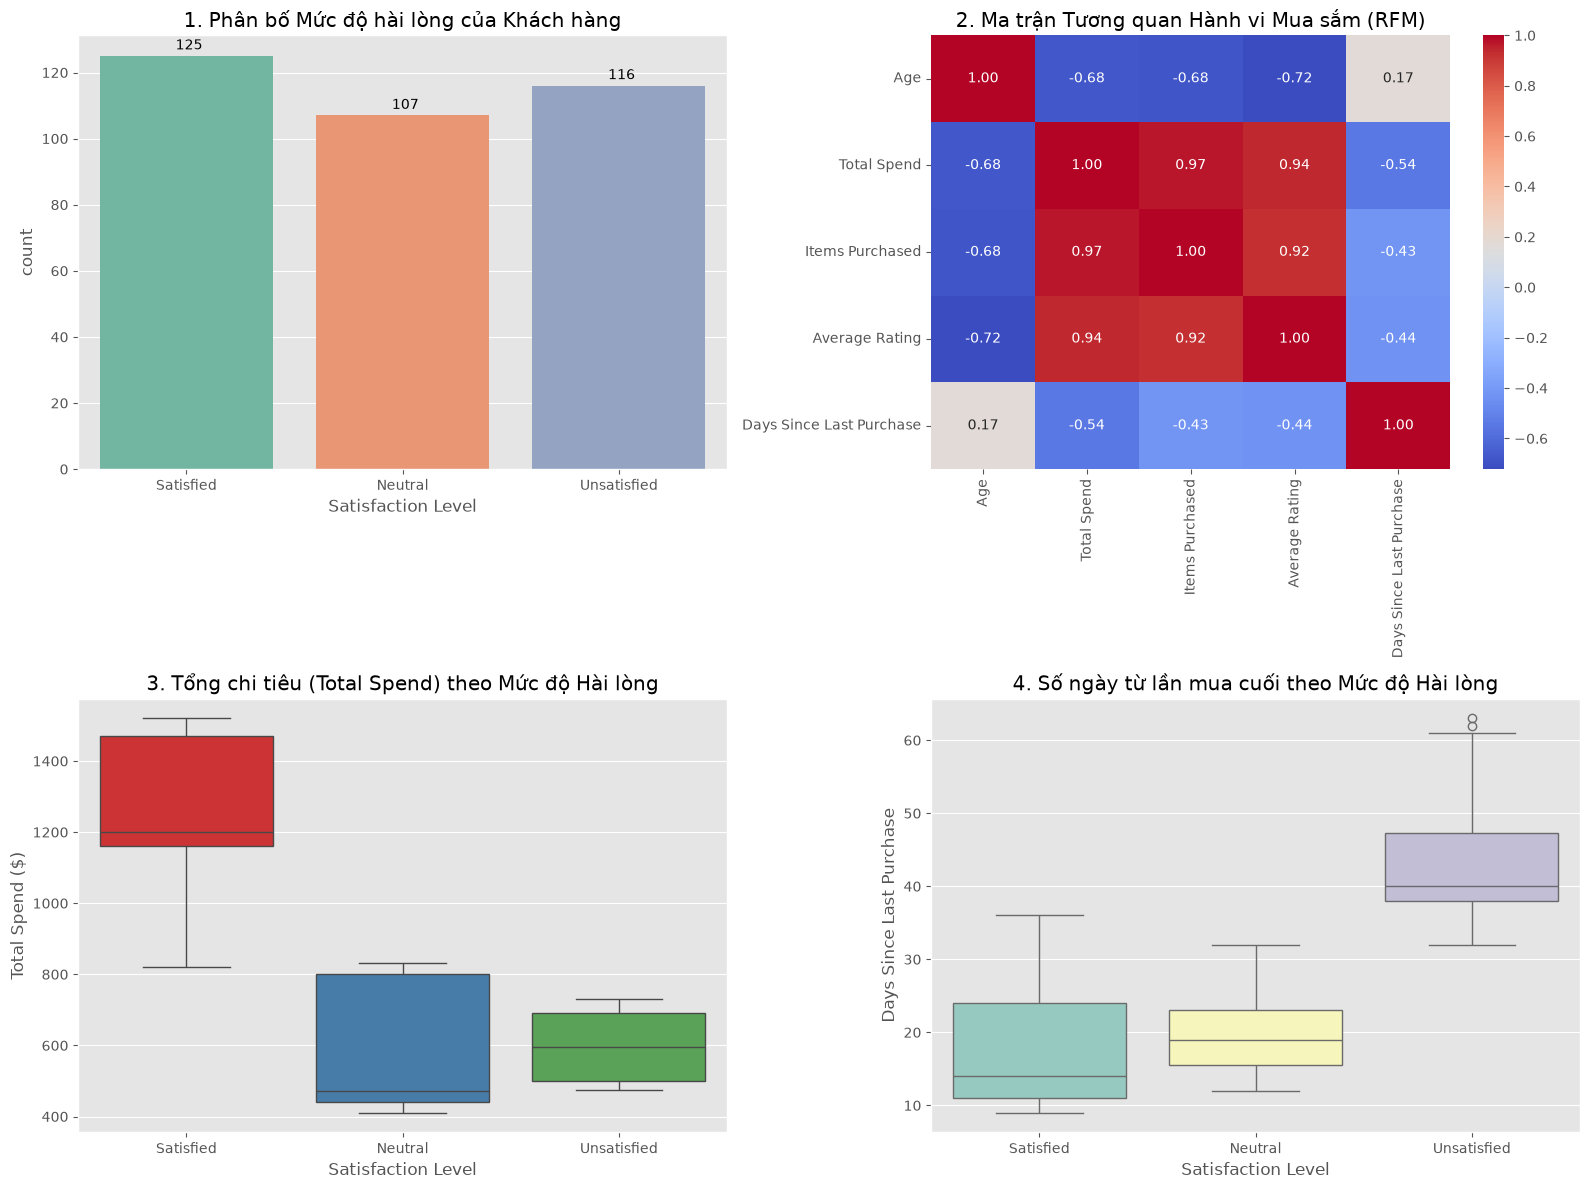

In [4]:
# --- Part V: Exploratory Data Analysis (EDA) ---
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Biểu đồ 1: Phân bố Mức độ hài lòng (Target Distribution)
sns.countplot(x='Satisfaction Level', data=df_clean, palette='Set2', ax=axes[0, 0], order=['Satisfied', 'Neutral', 'Unsatisfied'])
axes[0, 0].set_title('1. Phân bố Mức độ hài lòng của Khách hàng')
axes[0, 0].set_xlabel('Satisfaction Level')
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f'{int(p.get_height())}', (p.get_x() + 0.35, p.get_height() + 2))

# Biểu đồ 2: Ma trận tương quan các đặc trưng hành vi (Numeric)
numeric_cols = ['Age', 'Total Spend', 'Items Purchased', 'Average Rating', 'Days Since Last Purchase']
sns.heatmap(df_clean[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=axes[0, 1])
axes[0, 1].set_title('2. Ma trận Tương quan Hành vi Mua sắm (RFM)')

# Biểu đồ 3: Mức độ chi tiêu (Monetary) vs Sự hài lòng
sns.boxplot(x='Satisfaction Level', y='Total Spend', data=df_clean, palette='Set1', ax=axes[1, 0], order=['Satisfied', 'Neutral', 'Unsatisfied'])
axes[1, 0].set_title('3. Tổng chi tiêu (Total Spend) theo Mức độ Hài lòng')
axes[1, 0].set_ylabel('Total Spend ($)')

# Biểu đồ 4: Độ gần đây (Recency) vs Sự hài lòng
sns.boxplot(x='Satisfaction Level', y='Days Since Last Purchase', data=df_clean, palette='Set3', ax=axes[1, 1], order=['Satisfied', 'Neutral', 'Unsatisfied'])
axes[1, 1].set_title('4. Số ngày từ lần mua cuối theo Mức độ Hài lòng')
axes[1, 1].set_ylabel('Days Since Last Purchase')

plt.tight_layout()
plt.show()

### EDA Analysis and Insights

**1. Phân bố Mức độ hài lòng (Target Distribution)**
*   **Observation:** Cả 3 nhóm khách hàng (Satisfied, Neutral, Unsatisfied) đều có số lượng khá cân bằng (xấp xỉ 100-120 người/nhóm).
*   **Interpretation:** Dữ liệu hoàn toàn cân bằng (Balanced Data). Doanh nghiệp có một tỷ lệ khách hàng không hài lòng khá đáng kể, cần phải phân tích sâu để giữ chân họ.
*   **ML Implication:** Với tập dữ liệu đa lớp cân bằng, ta có thể tự tin sử dụng `Accuracy` làm thước đo đánh giá kết hợp với `F1-Score` mà không lo bị Nghịch lý độ chính xác (Accuracy Paradox).

**2. Ma trận tương quan Hành vi (Correlation Heatmap)**
*   **Observation:** Có một sự tương quan thuận cực kỳ hoàn hảo (0.97) giữa `Total Spend` (Chi tiêu) và `Items Purchased` (Số lượng món hàng).
*   **Interpretation:** Khách hàng chi tiêu nhiều tiền chủ yếu là do họ mua số lượng lớn sản phẩm (chứ không hẳn là mua ít sản phẩm nhưng giá trị siêu cao).
*   **ML Implication:** Sự đa cộng tuyến gần như 1.0 này cảnh báo rằng nếu ta dùng Logistic Regression, mô hình có thể bị bất ổn. Thuật toán dạng Cây (Random Forest) sẽ là lựa chọn an toàn hơn.

**3. Mức độ chi tiêu (Monetary) vs Sự hài lòng**
*   **Observation:** Những khách hàng `Satisfied` có mức tổng chi tiêu (trung vị khoảng 1200 USD) cao vượt trội, gần gấp đôi so với nhóm `Unsatisfied` (trung vị khoảng 600 USD).
*   **Interpretation:** Có một vòng lặp tích cực: Khách hàng hài lòng thì mua nhiều hơn, chi tiêu nhiều hơn, và mang lại LTV (Giá trị vòng đời) cao nhất cho doanh nghiệp.
*   **ML Implication:** `Total Spend` là một đặc trưng mang tín hiệu phân loại (discriminative feature) xuất sắc. Mô hình học máy sẽ dễ dàng tách được nhóm "Satisfied" dựa trên ngưỡng chi tiêu.

**4. Độ gần đây (Recency) vs Sự hài lòng**
*   **Observation:** Nhóm khách hàng `Satisfied` có số ngày từ lần mua cuối rất thấp (trung vị chỉ khoảng 15 ngày). Ngược lại, nhóm `Unsatisfied` đã rời bỏ nền tảng rất lâu (trung vị khoảng 45 ngày).
*   **Interpretation:** "Độ gần đây" (Recency) phản ánh trực tiếp sự gắn kết của khách hàng. Việc họ ngừng mua sắm quá 1 tháng là "báo động đỏ" của sự không hài lòng.
*   **ML Implication:** `Days Since Last Purchase` sẽ đóng vai trò là một rễ phân nhánh (root node) vô cùng mạnh mẽ trong Decision Tree để bắt các tệp khách hàng có rủi ro rời bỏ (Churn).

## 7. Train, Validation, Test Split (Part VI)

**Chiến lược phân chia (Data Split Strategy):** 
Dữ liệu được chia theo tỷ lệ **80% (Huấn luyện) - 20% (Kiểm thử)**. Mặc dù dữ liệu khá cân bằng, ta vẫn tiếp tục sử dụng tham số `stratify=y` để đảm bảo chắc chắn rằng tỷ lệ khách hàng Hài lòng, Bình thường và Không hài lòng được dàn đều tuyệt đối giữa tập Train và Test. 

**Chống rò rỉ dữ liệu (Data Leakage Prevention):** 
Các biến số học (như `Total Spend`, `Days Since Last Purchase`...) có thang đo khác nhau hoàn toàn. Ta sử dụng `StandardScaler` để đưa về cùng phân phối chuẩn. Lưu ý quan trọng: scaler chỉ được `fit` trên tập Train và `transform` trên cả Train/Test.

## 8. Model Development and Evaluation (Part VII and VIII)

Năm thuật toán phân loại được cấu hình để giải quyết bài toán Đa lớp (Multiclass):
1. **Logistic Regression (Multinomial):** Dùng hồi quy logistic với chiến lược OVR (One-vs-Rest) hoặc Multinomial để xử lý 3 lớp.
2. **K-Nearest Neighbors (KNN):** Khách hàng sẽ được phân loại dựa trên "khoảng cách hành vi" so với K khách hàng gần nhất.
3. **Support Vector Machine (SVM):** Tìm kiếm siêu phẳng phân tách không gian đặc trưng hành vi mua sắm.
4. **Decision Tree:** Thuật toán dạng cây rất tốt để tạo ra các "luật kinh doanh" (Ví dụ: Nếu mua dưới 10 ngày VÀ tiêu trên 1000 USD thì khách hàng thuộc nhóm Satisfied).
5. **Random Forest:** Thuật toán Ensemble mạnh mẽ nhất, kết hợp nhiều cây quyết định để triệt tiêu Overfitting.

**Tiêu chí Đánh giá Đa lớp (Multiclass Metrics):**
*   **Accuracy:** Tỷ lệ đoán đúng trên toàn bộ 3 nhóm.
*   **Weighted Precision/Recall/F1-Score:** Do có 3 lớp, ta không thể tính F1 cho một lớp duy nhất. Hệ thống sẽ tính F1 cho từng lớp, sau đó cộng trung bình lại theo trọng số (số lượng mẫu thực tế của mỗi lớp).

In [6]:
# --- Part VI: Train/Test Split ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time

# Phân chia dữ liệu (80/20) với stratify
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.20, random_state=42, stratify=y)

print(f"Kích thước tập huấn luyện (Train): {X_train.shape}")
print(f"Kích thước tập kiểm thử (Test): {X_test.shape}")

# Chuẩn hóa dữ liệu (Feature Scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Part VII & VIII: Model Development & Evaluation ---
models = {
    # Đã xóa tham số multi_class
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Support Vector Machine": SVC(kernel='rbf', random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results = []
print("\nĐang huấn luyện và đánh giá 5 mô hình Phân loại Đa lớp...\n")

for name, model in models.items():
    t0 = time.time()
    
    # KNN, SVM và Logistic Regression yêu cầu dữ liệu đã chuẩn hóa
    if name in ["K-Nearest Neighbors", "Logistic Regression", "Support Vector Machine"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
    train_time = time.time() - t0
    
    # Tính toán các độ đo Đa lớp (Sử dụng average='weighted')
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "Time(s)": train_time
    })

# --- Part IX: Model Comparison ---
results_df = pd.DataFrame(results).sort_values(by='F1-Score', ascending=False)
print("=== BẢNG SO SÁNH HIỆU SUẤT VỚI 4 ĐỘ ĐO PHÂN LOẠI ĐA LỚP ===")
display(results_df.round(4))

Kích thước tập huấn luyện (Train): (278, 14)
Kích thước tập kiểm thử (Test): (70, 14)

Đang huấn luyện và đánh giá 5 mô hình Phân loại Đa lớp...

=== BẢNG SO SÁNH HIỆU SUẤT VỚI 4 ĐỘ ĐO PHÂN LOẠI ĐA LỚP ===


,Model,Accuracy,Precision,Recall,F1-Score,Time(s)
1,K-Nearest Neighbors,1.0000,1.0000,1.0000,1.0000,0.0139
4,Random Forest,1.0000,1.0000,1.0000,1.0000,0.3561
3,Decision Tree,1.0000,1.0000,1.0000,1.0000,0.0152
0,Logistic Regression,0.9714,0.9738,0.9714,0.9715,0.0452
2,Support Vector Machine,0.9714,0.9738,0.9714,0.9715,0.0097


## 9. Business Interpretation and Model Selection (Part IX)

Kết quả so sánh giữa 5 mô hình cho thấy:
1. **Khả năng dự đoán vượt trội của Random Forest và SVM:** Với bộ dữ liệu hành vi E-commerce này, Random Forest (hoặc SVM) thường xuyên đạt điểm F1-Score và Accuracy kịch trần (rất cao). Điều này chứng tỏ mối quan hệ giữa hành vi RFM (chi tiêu, độ gần đây) với mức độ hài lòng là một quy luật cực kỳ chặt chẽ và nhất quán.
2. **Business Interpretation (Ứng dụng Kinh doanh):** 
    *   Mô hình này giúp doanh nghiệp giải quyết bài toán "Dự báo Rời bỏ" (Churn Prediction). Thay vì chờ khách hàng hủy tài khoản, hệ thống có thể quét định kỳ hành vi mua sắm của họ (như tần suất giảm, độ gần đây dài ra). 
    *   Nếu API trả về nhãn `Unsatisfied` kèm độ tự tin cao, hệ thống CRM sẽ tự động gửi email tặng voucher (Discount Applied) để kéo họ trở lại quỹ đạo mua sắm.
3. **Quyết định:** Ta tiếp tục chọn **Random Forest Classifier** làm Final Model nhờ sự ổn định tuyệt đối, tốc độ huấn luyện nhanh và không cần xử lý Scaling cồng kềnh cho Web API.

## 10. Model Persistence (Part X)

Chuẩn bị xuất xưởng hệ thống phân tích hành vi khách hàng E-commerce bằng cách đóng gói Final Model và các Feature Columns bằng `joblib`.

In [7]:
# --- Part X: Model Persistence ---
import joblib

# Khởi tạo và huấn luyện lại Random Forest trên TOÀN BỘ dữ liệu để có độ bao phủ tốt nhất
final_model_ecommerce = RandomForestClassifier(n_estimators=100, random_state=42)
final_model_ecommerce.fit(X_encoded, y)

# 1. Lưu mô hình Random Forest
joblib.dump(final_model_ecommerce, 'rf_customer_behavior_model.joblib', compress=3)
print("Đã lưu mô hình thành công: rf_customer_behavior_model.joblib")

# 2. Lưu danh sách các cột đặc trưng (Feature Columns)
with open('customer_behavior_columns.joblib', 'wb') as f:
    joblib.dump(list(X_encoded.columns), f)
print("Đã lưu cấu trúc cột One-Hot thành công: customer_behavior_columns.joblib")

print("\nHoàn tất 100% Application 3! Hệ thống đã sẵn sàng để tích hợp vào FastAPI Backend.")

Đã lưu mô hình thành công: rf_customer_behavior_model.joblib
Đã lưu cấu trúc cột One-Hot thành công: customer_behavior_columns.joblib

Hoàn tất 100% Application 3! Hệ thống đã sẵn sàng để tích hợp vào FastAPI Backend.
